In [ ]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. 예시 데이터 로드
# iris는 3개 품종(class)을 구분하는 대표적인 다중 분류 데이터
iris = load_iris()

X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name="target")

print("X shape:", X.shape)
print("y unique:", y.unique())

# 2. 학습용 / 테스트용 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 3. MDA(LDA) 모델 생성
# solver='svd'가 기본적이고 무난함
mda = LinearDiscriminantAnalysis(solver='svd')

# 4. 학습
mda.fit(X_train, y_train)

# 5. 예측
y_pred = mda.predict(X_test)

# 6. 평가
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("\n정확도:", acc)
print("\n혼동행렬:")
print(cm)
print("\n분류 리포트:")
print(report)

# 7. 클래스별 예측확률
proba = mda.predict_proba(X_test)
print("\n예측확률 상위 5개:")
print(proba[:5])

# 8. 판별축으로 변환
# 클래스가 3개면 최대 2개의 판별축이 나옴
X_train_lda = mda.transform(X_train)
X_test_lda = mda.transform(X_test)

print("\n변환된 학습 데이터 shape:", X_train_lda.shape)
print("변환된 테스트 데이터 shape:", X_test_lda.shape)

# 9. 판별계수 확인
# coef_: 각 클래스 구분에 쓰이는 계수
print("\n판별계수(coef_):")#각 클래스별 결정 경계 방향 (weight)
# 각 feature가 분류에 얼마나 영향을 주는지
# 값이 크면 영향 큼
print(pd.DataFrame(mda.coef_, columns=X.columns))
print("\LD1, LD2 축을 만드는 계수(scalings_):")
print(pd.DataFrame(mda.scalings_, columns=["LD1", "LD2"], index=X.columns))

# 10. 절편
# lda.intercept_
# 👉 decision boundary의 bias
print("\n절편(intercept_):")
print(mda.intercept_)
# lda.means_
# 👉 각 클래스의 평균 벡터
# lda.explained_variance_ratio_
# 👉 각 LDA 축이 얼마나 클래스 분리를 잘 하는지

X shape: (150, 4)
y unique: [0 1 2]

정확도: 1.0

혼동행렬:
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]

분류 리포트:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


예측확률 상위 5개:
[[1.00000000e+00 2.65739808e-17 7.83648281e-37]
 [1.38434666e-29 1.39129232e-01 8.60870768e-01]
 [1.21624258e-13 9.99999955e-01 4.47512360e-08]
 [6.55209421e-14 9.99999955e-01 4.46287529e-08]
 [1.00000000e+00 1.33360092e-18 2.05254820e-38]]

변환된 학습 데이터 shape: (120, 2)
변환된 테스트 데이터 shape: (30, 2)

판별계수(coef_):
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0           6.942597         11.057238         -17.706414        -20.053905
1          -1.831986         -3.903011       

In [ ]:
mda.scalings_,

(array([[ 0.90434595, -0.31621878],
        [ 1.39795882, -1.89052691],
        [-2.2936657 ,  1.22489719],
        [-2.7365354 , -3.15617309]]),)

원변수 → coef_, intercept_ → 클래스별 score 계산 → 가장 큰 클래스 선택
6. 왜 둘이 다르냐?

이유는 목적이 다르기 때문이야.

scalings_
데이터를 판별축 공간으로 변환
시각화, LD1/LD2 해석용
coef_
실제 클래스 구분 결정함수
예측용

같은 LDA 모델 안에 있지만 보는 관점이 다름.


/opt/homebrew/Caskroom/miniforge/base/envs/adp/lib/python3.7/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/Caskroom/miniforge/base/envs/adp/lib/python3.7/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/Caskroom/miniforge/base/envs/adp/lib/python3.7/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/Caskroom/miniforge/base/envs/adp/lib/python3.7/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/Caskroom/miniforge/base/envs/adp/lib/python3.7/site-packages/IPython/core/pyl

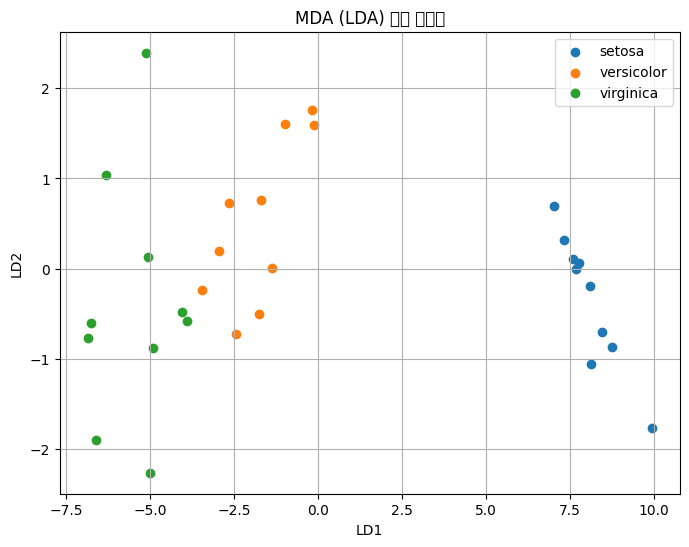

In [2]:
import matplotlib.pyplot as plt

# 테스트 데이터를 판별축 공간으로 변환
X_test_lda = mda.transform(X_test)

plt.figure(figsize=(8, 6))

for class_value in np.unique(y_test):
    idx = y_test == class_value
    plt.scatter(
        X_test_lda[idx, 0],
        X_test_lda[idx, 1],
        label=iris.target_names[class_value]
    )

plt.xlabel("LD1")
plt.ylabel("LD2")
plt.title("MDA (LDA) 결과 시각화")
plt.legend()
plt.grid(True)
plt.show()